# Nouveau module (DR-HyperCF) sur tous les jeux DLBAC

Ce notebook :
1. charge les données préparées (`prepare_dlbac_datasets.py`) ;
2. entraîne le modèle `nouveau_module` sur chaque jeu **entraînable** ;
3. affiche un tableau récapitulatif (accuracy, contrefactuels) ;
4. montre des **règles** et des **contrefactuels** pour un échantillon par jeu.

Prérequis : `python prepare_dlbac_datasets.py --all` depuis `HyConEx_from_scratch/`.



In [ ]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Racine HyConEx_from_scratch : cwd peut être le dossier du notebook ou le repo
_cwd = Path.cwd().resolve()
ROOT = None
for p in (_cwd, _cwd.parent):
    if (p / "prepare_dlbac_datasets.py").is_file():
        ROOT = p
        break
if ROOT is None:
    raise FileNotFoundError(
        "prepare_dlbac_datasets.py introuvable. Ouvrez le notebook depuis notebooks/ "
        "ou depuis HyConEx_from_scratch/."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if "prepare_dlbac_datasets" in sys.modules:
    importlib.reload(sys.modules["prepare_dlbac_datasets"])

from prepare_dlbac_datasets import (
    DEFAULT_OUT_DIR,
    explain_counterfactual_flip,
    format_rule,
    list_trainable_prepared,
    load_prepared,
)
from nouveau_module import HybridDRConfig, HybridDRTrainer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
PREPARED_DIR = DEFAULT_OUT_DIR
RESULTS_DIR = ROOT / "results" / "nouveau_module_dlbac"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = list_trainable_prepared(PREPARED_DIR)
print(f"Jeux entraînables ({len(DATASETS)}):", DATASETS)

Jeux entraînables (11): ['amazon1', 'amazon2', 'amazon3', 'u4k-r4k-auth11k', 'u4k-r4k-auth21k', 'u4k-r4k-auth22k', 'u4k-r6k-auth28k', 'u4k-r7k-auth20k', 'u5k-r5k-auth12k', 'u5k-r5k-auth19k', 'u6k-r6k-auth32k']


## Hyperparamètres

Les jeux Amazon ont une dimension one-hot très élevée : on limite optionnellement le nombre de colonnes (variance) pour un entraînement raisonnable sur machine locale.

In [2]:
SEED = 42
EPOCHS_SYNTH = 30
EPOCHS_AMAZON = 20
MAX_FEATURES_HIGH_DIM = 512  # None pour désactiver la réduction
HIGH_DIM_THRESHOLD = 800


def select_top_variance_features(x_train, x_val, x_test, max_features: int):
    var = x_train.var(axis=0)
    idx = np.argsort(var)[::-1][:max_features]
    return x_train[:, idx], x_val[:, idx], x_test[:, idx], idx


def config_for_dataset(name: str, num_classes: int, n_features: int) -> HybridDRConfig:
    is_amazon = name.startswith("amazon")
    epochs = EPOCHS_AMAZON if is_amazon else EPOCHS_SYNTH
    batch = 256 if n_features < 500 else 128
    num_rules = min(128, 32 + 6 * num_classes) if not is_amazon else min(64, 32)
    hidden = 128 if n_features < 500 else 96
    return HybridDRConfig(
        seed=SEED,
        epochs=epochs,
        batch_size=batch,
        lr=1e-3,
        num_rules=num_rules,
        hyper_hidden_dim=hidden,
        cf_hidden_dim=hidden,
        tabresnet_n_blocks=3 if n_features > 500 else 4,
        bins_per_feature=4,
        input_encoding="bipolar",
        use_class_weights=True,
        early_stop_metric="auto",
        temperature=0.6 if num_classes > 2 else 0.8,
        cf_lambda=0.08 if num_classes > 2 else 0.12,
        flip_lambda=0.04,
        rule_sparsity_lambda=0.001,
    )


def train_one_dataset(name: str) -> dict:
    splits = load_prepared(name, PREPARED_DIR)
    x_train, x_val, x_test = splits.x_train, splits.x_val, splits.x_test
    feature_idx = None
    if MAX_FEATURES_HIGH_DIM and splits.num_features > HIGH_DIM_THRESHOLD:
        x_train, x_val, x_test, feature_idx = select_top_variance_features(
            x_train, x_val, x_test, MAX_FEATURES_HIGH_DIM
        )
    n_feat = x_train.shape[1]
    cfg = config_for_dataset(name, splits.num_classes, n_feat)
    feat_names = [f"feat_{i}" for i in range(n_feat)]
    trainer = HybridDRTrainer(cfg)
    result = trainer.fit(
        x_train,
        splits.y_train,
        x_val_cont=x_val,
        y_val=splits.y_val,
        feature_names=feat_names,
        class_names=splits.class_names,
        verbose=True,
    )
    metrics = trainer.evaluate(x_test, splits.y_test, counterfactuals=True)
    rules = trainer.export_rules(top_per_rule=4, min_abs_weight=0.05)
    return {
        "dataset": name,
        "kind": splits.kind,
        "num_features_used": n_feat,
        "num_features_raw": splits.num_features,
        "feature_selection": feature_idx is not None,
        "num_classes": splits.num_classes,
        "epochs": cfg.epochs,
        "binarizer_mode": trainer.binarizer.mode_,
        "best_val_accuracy": result.best_val_accuracy,
        "best_val_auroc": result.best_val_auroc,
        "test_accuracy": metrics["accuracy"],
        "test_auroc": metrics.get("auroc_ovr"),
        "cf_validity": metrics["counterfactuals"]["validity_cf"],
        "cf_changed_bits": metrics["counterfactuals"]["changed_bits_mean"],
        "cf_proximity_l1": metrics["counterfactuals"]["proximity_l1_cont_mean"],
        "n_rules": len(rules),
        "rules_top5": rules[:5],
        "trainer": trainer,
        "x_test": x_test,
        "y_test": splits.y_test,
    }

## Entraînement sur tous les jeux

In [ ]:
all_results: list[dict] = []
trained: dict[str, dict] = {}

for ds_name in DATASETS:
    print("\n" + "=" * 72)
    print(f"Dataset: {ds_name}")
    print("=" * 72)
    row = train_one_dataset(ds_name)
    trained[ds_name] = row
    summary = {k: v for k, v in row.items() if k not in {"trainer", "x_test", "y_test", "rules_top5"}}
    all_results.append(summary)

summary_df = pd.DataFrame(all_results)
summary_path = RESULTS_DIR / "summary_metrics.csv"
summary_df.to_csv(summary_path, index=False)
summary_df


Dataset: amazon1
[Epoch 001/20] loss=1.2108 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 002/20] loss=1.1731 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 003/20] loss=1.1704 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 004/20] loss=1.1647 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 005/20] loss=1.1724 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 006/20] loss=1.1714 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 007/20] loss=1.1737 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 008/20] loss=1.1372 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 009/20] loss=1.1033 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 010/20] loss=0.8734 val_acc=0.9424 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 011/20] loss=0.8101 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 012/20] loss=0.8968 val_acc=0.0576 val_auroc=0.5000 best(auroc)=0.5000
[Epoch 013/20] loss=0.8673 val_acc=0.0576 val_

## Visualisation des métriques

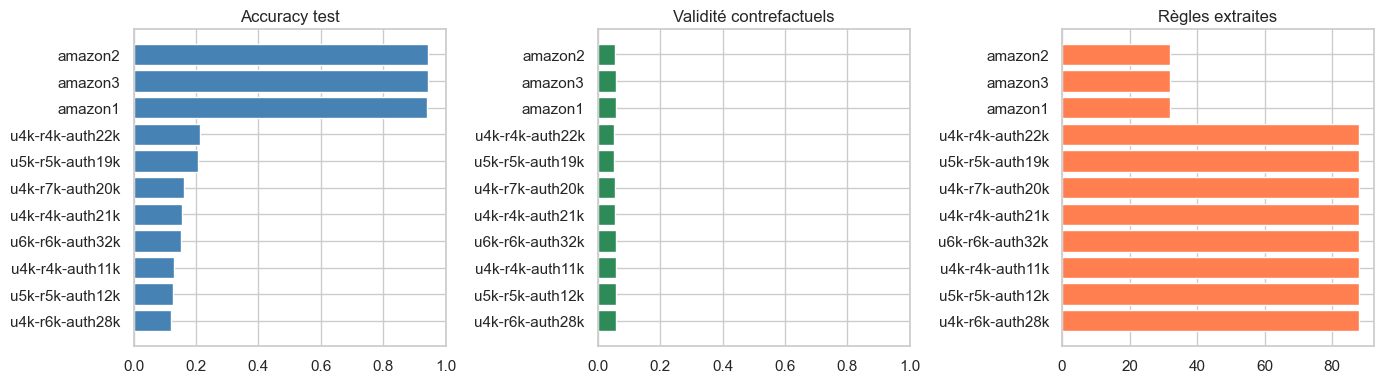

In [ ]:
plot_df = summary_df.sort_values("test_accuracy", ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(14, max(4, 0.35 * len(plot_df))))

axes[0].barh(plot_df["dataset"], plot_df["test_accuracy"], color="steelblue")
axes[0].set_title("Accuracy test")
axes[0].set_xlim(0, 1)

axes[1].barh(plot_df["dataset"], plot_df["cf_validity"], color="seagreen")
axes[1].set_title("Validité contrefactuels")
axes[1].set_xlim(0, 1)

axes[2].barh(plot_df["dataset"], plot_df["n_rules"], color="coral")
axes[2].set_title("Règles extraites")
plt.tight_layout()
plt.show()

## Explications : règles et contrefactuels (par jeu)

Pour chaque jeu : les **5 meilleures règles** et un **contrefactuel** vers une classe alternative pour un échantillon du test.

In [ ]:
for ds_name, row in trained.items():
    trainer = row["trainer"]
    x_test = row["x_test"]
    y_test = row["y_test"]
    class_names = trainer.class_names

    print("\n" + "#" * 72)
    print(f"## {ds_name} ({row['kind']})")
    print(f"Accuracy test: {row['test_accuracy']:.4f} | CF validité: {row['cf_validity']:.4f}")
    print("#" * 72)

    print("\n--- Règles (top 5) ---")
    for i, rule in enumerate(row["rules_top5"], start=1):
        print(f"{i}. {format_rule(rule)}")

    idx = 0
    y_true = int(y_test[idx])
    x_bin = trainer.binarizer.transform(x_test[idx : idx + 1])
    with torch.no_grad():
        logits = trainer.model.predict_logits(
            torch.tensor(x_bin, dtype=torch.float32, device=trainer.device)
        )
    y_pred = int(torch.argmax(logits, dim=1).item())

    alt_classes = [c for c in range(row["num_classes"]) if c != y_true]
    if not alt_classes:
        print("\n(Pas de classe alternative pour l'exemple.)")
        continue
    target = alt_classes[0]

    cf = explain_counterfactual_flip(trainer, x_test, idx, target, y_true=y_true)
    print(f"\n--- Contrefactuel (échantillon {idx}) ---")
    print(f"Vraie classe: {class_names[y_true]} | Prédite: {class_names[y_pred]}")
    print(f"Cible CF: {cf['y_target_name']} | Prédite sur x': {class_names[cf['y_pred_cf']]}")
    print(f"Valide: {cf['valid']} | Nb flips: {cf['n_flips']}")
    if cf["flips"]:
        print("Modifications (extrait):")
        for flip in cf["flips"][:8]:
            print(f"  - {flip['feature']}: {flip['from']} -> {flip['to']}")
    else:
        print("Aucun littéral modifié.")


########################################################################
## amazon1 (real_world)
Accuracy test: 0.9408 | CF validité: 0.0592
########################################################################

--- Règles (top 5) ---
1. IF f423_bin0_[0.000,1.000)=+1 AND f175_bin0_[0.000,1.000)=-1 AND f9_bin0_[0.000,1.000)=-1 AND f204_bin0_[0.000,1.000)=-1 THEN deny (score=0.974)
2. IF f58_bin0_[0.000,1.000)=+1 AND f468_bin0_[0.000,1.000)=-1 AND f167_bin0_[0.000,1.000)=+1 AND f148_bin0_[0.000,1.000)=-1 THEN grant (score=0.967)
3. IF f101_bin0_[0.000,1.000)=+1 AND f99_bin0_[0.000,1.000)=-1 AND f329_bin0_[0.000,1.000)=+1 AND f201_bin0_[0.000,1.000)=-1 THEN grant (score=0.944)
4. IF f509_bin0_[0.000,1.000)=+1 AND f342_bin0_[0.000,1.000)=+1 AND f202_bin0_[0.000,1.000)=+1 AND f115_bin0_[0.000,1.000)=-1 THEN deny (score=0.929)
5. IF f431_bin0_[0.000,1.000)=-1 AND f336_bin0_[0.000,1.000)=-1 AND f23_bin0_[0.000,1.000)=-1 AND f235_bin0_[0.000,1.000)=-1 THEN grant (score=0.896)

--- Contrefa

## Sauvegarde des règles par jeu

In [ ]:
for ds_name, row in trained.items():
    out = {
        "dataset": ds_name,
        "metrics": {k: row[k] for k in row if k not in {"trainer", "x_test", "y_test", "rules_top5"}},
        "rules": row["rules_top5"],
    }
    path = RESULTS_DIR / f"{ds_name}_explanations.json"
    path.write_text(json.dumps(out, indent=2, default=str), encoding="utf-8")
    print(f"Sauvegardé: {path}")

Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\amazon1_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\amazon2_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\amazon3_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\u4k-r4k-auth11k_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\u4k-r4k-auth21k_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\u4k-r4k-auth22k_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\nouveau_module_dlbac\u4k-r6k-auth28k_explanations.json
Sauvegardé: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results